# Predictia categoriei produsului pe baza titlului

**Curs:** Introduction to Machine Learning Using Python
**Modul:** Crearea unui model ML pentru clasificare

Acest notebook documenteaza intregul proces de dezvoltare a unui model care
prezice categoria unui produs (`Category Label`) pe baza titlului sau
(`Product Title`), folosind setul de date `products.csv`.

Structura notebook-ului:
1. Incarcare si explorare date
2. Curatare si pregatire date
3. Inginerie caracteristici (feature engineering)
4. Impartire train/test
5. Vectorizare text + preprocesare
6. Antrenare si comparare modele
7. Evaluare (acuratete, raport de clasificare, matrice de confuzie)
8. Salvarea modelului final
9. Concluzie


## 1. Import biblioteci

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from features import build_features, NUMERIC_FEATURE_COLUMNS


## 2. Incarcarea si explorarea datelor

Incarcam `products.csv` si aruncam o privire generala: cate produse avem,
cate categorii distincte, si daca exista valori lipsa in coloanele care ne
intereseaza (`Product Title`, `Category Label`).

In [35]:
TITLE_COLUMN = "Product Title"
CATEGORY_COLUMN = "Category Label"

df = pd.read_csv("products.csv")

# IMPORTANT: products.csv are spatii ascunse in unele nume de coloane
# (ex: " Category Label" in loc de "Category Label"). Le curatam imediat.
df.columns = df.columns.str.strip()

print(f"Numar total de produse: {len(df)}")
display(df.head())

print("\nValori lipsa pe coloane:")
print(df.isnull().sum())

print(f"\nNumar de categorii distincte: {df[CATEGORY_COLUMN].nunique()}")


Numar total de produse: 35311


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023



Valori lipsa pe coloane:
product ID           0
Product Title      172
Merchant ID          0
Category Label      44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
Listing Date        59
dtype: int64

Numar de categorii distincte: 13


### Distributia categoriilor

Cate produse are fiecare categorie? E important sa stim daca unele categorii au foarte putine exemple - acestea sunt mai greu de invatat de catre model.

Category Label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


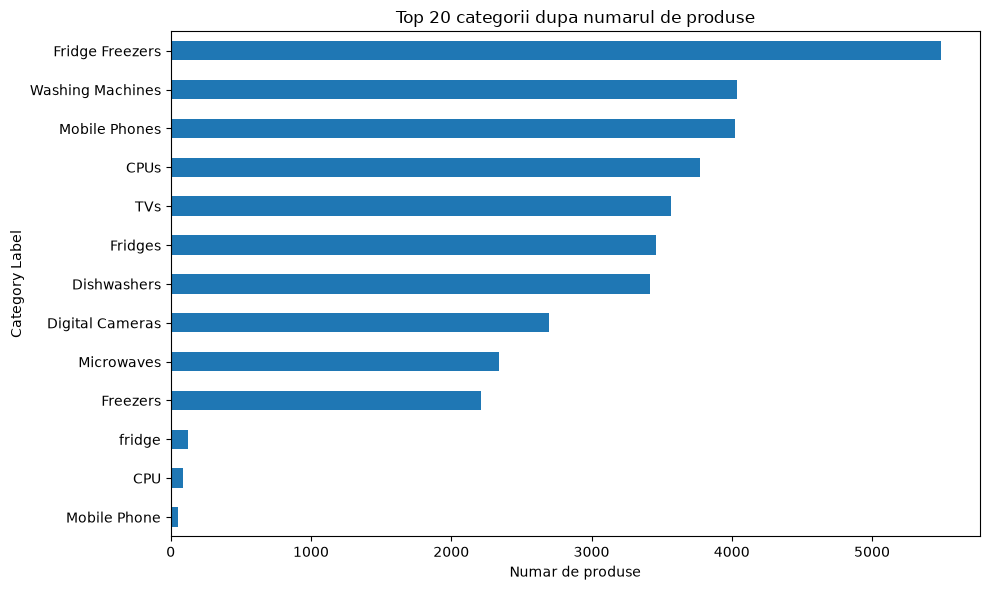

In [36]:
category_counts = df[CATEGORY_COLUMN].value_counts()
print(category_counts)

plt.figure(figsize=(10, 6))
category_counts.head(20).plot(kind="barh")
plt.title("Top 20 categorii dupa numarul de produse")
plt.xlabel("Numar de produse")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 3. Curatarea datelor

- Eliminam produsele fara titlu sau fara categorie.
- Standardizam textul categoriei (eliminam spatii in plus).
- Eliminam categoriile cu mai putin de 2 produse - acestea nu pot fi
  impartite corect intre setul de antrenament si cel de testare
  (train_test_split cu stratify are nevoie de cel putin 2 exemple per clasa).

In [37]:
df = df.dropna(subset=[TITLE_COLUMN, CATEGORY_COLUMN])
df[CATEGORY_COLUMN] = df[CATEGORY_COLUMN].astype(str).str.strip()

# PROBLEMA GASITA IN DATELE REALE: aceeasi categorie apare scrisa in mai
# multe feluri - ex: "CPU" vs "CPUs", "Mobile Phone" vs "Mobile Phones",
# "fridge" (litere mici) vs "Fridges". Le normalizam si le unificam sub
# forma cea mai frecventa, ca sa nu creeze categorii artificiale separate.
def _normalize_category(cat):
    cat = cat.strip().lower()
    if cat.endswith("s") and not cat.endswith("ss"):
        cat = cat[:-1]
    return cat

df["_category_normalized"] = df[CATEGORY_COLUMN].apply(_normalize_category)
canonical_names = (
    df.groupby("_category_normalized")[CATEGORY_COLUMN]
    .agg(lambda values: values.value_counts().idxmax())
)
df[CATEGORY_COLUMN] = df["_category_normalized"].map(canonical_names)
df = df.drop(columns=["_category_normalized"])

valid_categories = category_counts[category_counts >= 2].index
df = df[df[CATEGORY_COLUMN].isin(valid_categories)]

print(f"Produse ramase dupa curatare: {len(df)}")
print(f"Categorii ramase: {df[CATEGORY_COLUMN].nunique()}")


Produse ramase dupa curatare: 35096
Categorii ramase: 10


## 4. Ingineria caracteristicilor (Feature Engineering)

Pe langa textul titlului, adaugam caracteristici suplimentare care ar putea
ajuta modelul sa distinga mai bine intre categorii:

- **title_word_count** - numarul de cuvinte din titlu (titluri tehnice, cu
  multe specificatii, pot avea mai multe cuvinte)
- **title_char_count** - lungimea totala a titlului
- **has_digit** - daca titlul contine cifre (frecvent la modele/specificatii,
  ex: "128GB", "A52")
- **has_special_char** - daca titlul contine caractere speciale
- **has_all_caps_word** - daca exista un cuvant scris integral cu majuscule
  (ex: "USB", "LED", "HD") - poate indica anumite categorii de electronice
- **longest_word_length** - lungimea celui mai lung cuvant

Functia `build_features` e definita in `features.py`, ca sa fie reutilizata
identic si de scripturile `train_model.py` / `predict_category.py`.

In [38]:
df = build_features(df, title_column=TITLE_COLUMN)
display(df[[TITLE_COLUMN] + NUMERIC_FEATURE_COLUMNS].head())


,Product Title,title_word_count,title_char_count,has_digit,has_special_char,has_all_caps_word,longest_word_length
0,apple iphone 8 plus 64gb silver,6,31,1,0,0,6
1,apple iphone 8 plus 64 gb spacegrau,7,35,1,0,0,9
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,13,70,1,1,0,10
3,apple iphone 8 plus 64gb space grey,7,35,1,0,0,6
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,11,54,1,1,0,8


## 5. Impartirea datelor (train/test split)

Impartim in 80% antrenament / 20% testare, cu `stratify` pe categorie -
astfel, fiecare categorie e reprezentata proportional in ambele seturi.

In [39]:
feature_columns = [TITLE_COLUMN] + NUMERIC_FEATURE_COLUMNS
X = df[feature_columns]
y = df[CATEGORY_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Produse de antrenament: {len(X_train)}")
print(f"Produse de testare: {len(X_test)}")


Produse de antrenament: 28076
Produse de testare: 7020


## 6. Preprocesare - TF-IDF + caracteristici numerice

Folosim `ColumnTransformer` ca sa aplicam:
- `TfidfVectorizer` pe coloana de text (`Product Title`)
- `StandardScaler` pe caracteristicile numerice

Rezultatul e combinat automat intr-o singura matrice de caracteristici,
gata de folosit de orice model de clasificare.

In [40]:
# Folosim MinMaxScaler (nu StandardScaler) pentru caracteristicile numerice,
# deliberat: StandardScaler poate produce valori negative, iar unul din
# modelele comparate mai jos (MultinomialNB) accepta DOAR valori nenegative.
preprocessor = ColumnTransformer(transformers=[
    ("tfidf", TfidfVectorizer(max_features=5000), TITLE_COLUMN),
    ("numeric", MinMaxScaler(), NUMERIC_FEATURE_COLUMNS),
])


## 7. Antrenarea si compararea mai multor modele

Testam trei algoritmi diferiti, fiecare impachetat intr-un `Pipeline`
(preprocesare + model), ca sa putem compara corect performanta lor:

- **Logistic Regression** - standard, rapid, robust
- **Multinomial Naive Bayes** - clasic pentru clasificare de text
- **Linear SVC** - de multe ori foarte performant pe text vectorizat TF-IDF

Evaluam fiecare model pe: acuratete, F1 (weighted - relevant cand avem multe
categorii, posibil dezechilibrate) si raport de clasificare complet.

In [41]:
candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVC": LinearSVC(),
}

trained_pipelines = {}
results_summary = []

for name, classifier in candidate_models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier),
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    trained_pipelines[name] = (pipeline, y_pred)
    results_summary.append({"Model": name, "Acuratete": acc, "F1 (weighted)": f1})

    print("=" * 70)
    print(f"Model: {name}")
    print(f"Acuratete: {acc:.4f}  |  F1 (weighted): {f1:.4f}")
    print("\nRaport de clasificare (rezumat):")
    print(classification_report(y_test, y_pred, zero_division=0))


Model: Logistic Regression
Acuratete: 0.9571  |  F1 (weighted): 0.9571

Raport de clasificare (rezumat):
                  precision    recall  f1-score   support

            CPUs       1.00      0.99      1.00       766
 Digital Cameras       1.00      0.99      0.99       538
     Dishwashers       0.97      0.92      0.94       681
        Freezers       0.98      0.93      0.95       440
 Fridge Freezers       0.91      0.95      0.93      1094
         Fridges       0.90      0.89      0.89       712
      Microwaves       0.98      0.96      0.97       466
   Mobile Phones       0.99      1.00      0.99       812
             TVs       0.97      0.99      0.98       708
Washing Machines       0.93      0.95      0.94       803

        accuracy                           0.96      7020
       macro avg       0.96      0.96      0.96      7020
    weighted avg       0.96      0.96      0.96      7020

Model: Multinomial Naive Bayes
Acuratete: 0.9195  |  F1 (weighted): 0.9182

Rapo

### Tabel comparativ

In [42]:
summary_df = pd.DataFrame(results_summary).sort_values(by="F1 (weighted)", ascending=False)
display(summary_df)


,Model,Acuratete,F1 (weighted)
2,Linear SVC,0.961823,0.961848
0,Logistic Regression,0.957123,0.957128
1,Multinomial Naive Bayes,0.919516,0.918196


## 8. Matricea de confuzie pentru cel mai bun model

Cu multe categorii, o matrice de confuzie completa poate fi greu de citit -
ne concentram pe **top 15 cele mai frecvente categorii**, ca sa pastram
graficul lizibil.

Cel mai bun model: Linear SVC


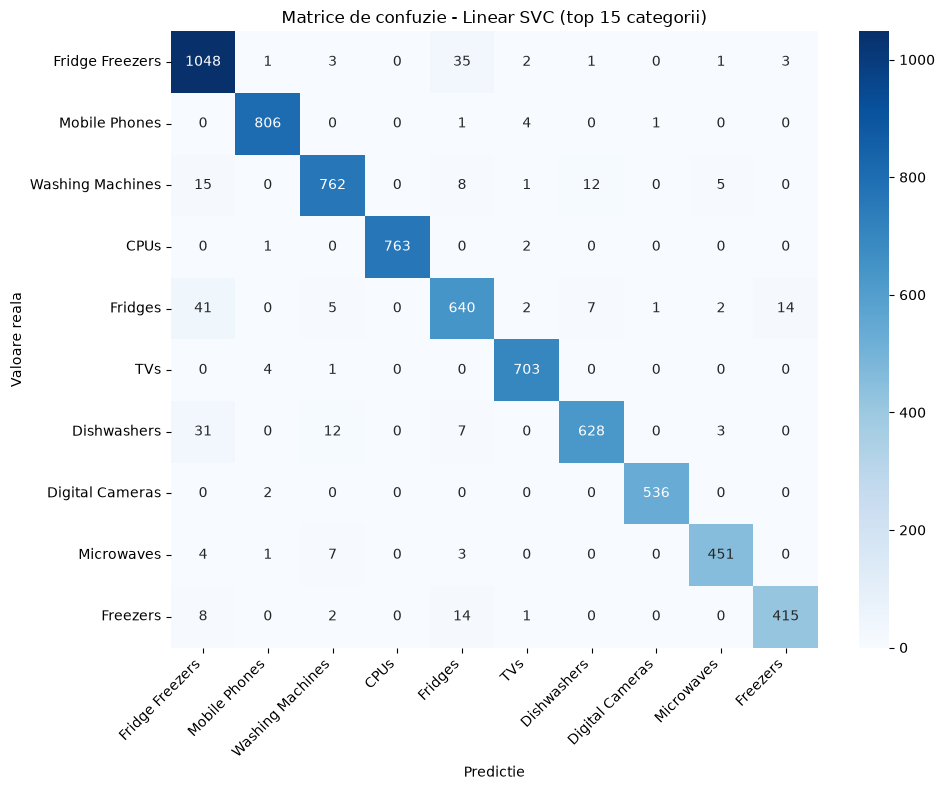

In [43]:
best_model_name = summary_df.iloc[0]["Model"]
best_pipeline, best_y_pred = trained_pipelines[best_model_name]

print(f"Cel mai bun model: {best_model_name}")

top_categories = y_test.value_counts().head(15).index.tolist()

cm = confusion_matrix(y_test, best_y_pred, labels=top_categories)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=top_categories, yticklabels=top_categories)
plt.title(f"Matrice de confuzie - {best_model_name} (top 15 categorii)")
plt.xlabel("Predictie")
plt.ylabel("Valoare reala")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 9. Salvarea modelului final

Salvam pipeline-ul castigator (preprocesare + model antrenat) intr-un fisier
`.pkl`, ca sa poata fi incarcat direct de `predict_category.py`, fara sa
retrenam nimic.

In [44]:
import pickle

with open("category_model.pkl", "wb") as f:
    pickle.dump(best_pipeline, f)

print("Model salvat in category_model.pkl")


Model salvat in category_model.pkl


## 10. Concluzie

- Modelul cu cea mai buna performanta a fost: Linear SVC, cu acuratete 0.9618 
  si F1 (weighted) 0.9618 - cel mai bun rezultat pe ambele metrici.

- Cum s-au comportat celelalte modele: Logistic Regression a fost foarte 
  aproape de Linear SVC (acuratete 0.9571), diferenta fiind mica. Multinomial 
  Naive Bayes a ramas vizibil in urma (0.9195), in special din cauza unei 
  singure categorii - "Freezers" - unde recall-ul a scazut la doar 0.52, 
  fata de peste 0.89 la toate celelalte categorii.

- Ce categorii sunt cel mai des confundate intre ele: "Fridges" si 
  "Freezers" par sa fie confundate cel mai des cu "Fridge Freezers" - 
  probabil pentru ca titlurile acestor produse contin cuvinte foarte 
  asemanatoare (frigider, congelator, combina frigorifica), ceea ce ingreuneaza 
  distinctia bazata doar pe text. Acest lucru se vede clar la Naive Bayes, 
  care e mult mai sensibil la aceasta suprapunere de vocabular decat 
  Linear SVC sau Logistic Regression.

- Ce caracteristici suplimentare au avut impact: caracteristicile numerice 
  adaugate (numar de cuvinte, prezenta cifrelor etc.) au ajutat modelul sa 
  distinga bine categorii cu tipare clare in titlu (ex: telefoane cu 
  capacitate de stocare gen "64GB", "128GB"), dar nu au fost suficiente 
  pentru a rezolva complet confuzia dintre categoriile de electrocasnice 
  mari, cu vocabular similar.

- Modelul final ales pentru echipa: Linear SVC, pentru ca are cea mai buna 
  performanta generala si cel mai bun echilibru intre precizie si recall pe 
  toate categoriile, inclusiv pe cele mai dificile (Fridges, Dishwashers).

### Observatii si dileme intalnite pe parcurs
- Cea mai mare provocare a fost: intelegerea ColumnTransformer pentru combinarea textului cu 
  caracteristicile numerice.

- Ce as imbunatati intr-o versiune viitoare: as incerca sa adaug caracteristici 
  suplimentare care sa ajute la distingerea Fridges/Freezers/Fridge Freezers 
  (de exemplu, cautarea explicita a cuvintelor cheie specifice fiecarei 
  categorii), si as testa si alti algoritmi precum Random Forest sau 
  ajustarea hiperparametrilor la Linear SVC.